In [1]:
# Install kaggle package
!pip install -q kaggle

In [2]:
# Upload Kaggle Api (kaggle.json) to Colab
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ronokrahman","key":"6723ec683f597882580d80dbc1acbc43"}'}

In [3]:
# Configure the kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Now Download the Dataset from kaggle using Dataset IDs
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 203MB/s]



In [5]:
# Now Unzip the dataset
!unzip -q chest-xray-pneumonia.zip -d /content/

In [40]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import  inception_v3, Inception_V3_Weights
from collections import Counter
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import seaborn as sns
import numpy as np
import os
import copy


In [7]:
# Select a Device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [41]:
# Create pathway variable for the dataset
train_dir='/content/chest_xray/train'
test_dir='/content/chest_xray/test'
val_dir='/content/chest_xray/val'

In [43]:
# Image Preprocessing:
# Transform the train dataset
train_transform=transforms.Compose([
    transforms.Resize((299,299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])    # Here use image net normalization

In [44]:
# Transform the validation dataset
val_transform=transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

In [45]:
# Transform the test dataset
test_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [46]:
# Load Dataset
train_dataset=datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)
val_dataset=datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)
test_dataset=datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)


Classes: ['NORMAL', 'PNEUMONIA']
Class to index: {'NORMAL': 0, 'PNEUMONIA': 1}


In [47]:
# Count labels in training dataset
train_counts = Counter(train_dataset.targets)

# Print class-wise count
for class_name, class_index in train_dataset.class_to_idx.items():
    print(f"{class_name}: {train_counts[class_index]} images")

NORMAL: 1341 images
PNEUMONIA: 3875 images


In [48]:
# Percentages of the datasset
total = len(train_dataset)

for class_name, class_index in train_dataset.class_to_idx.items():
    count = train_counts[class_index]
    percentage = (count / total) * 100

    print(f"{class_name}: {count} images ({percentage:.2f}%)")

NORMAL: 1341 images (25.71%)
PNEUMONIA: 3875 images (74.29%)


In [49]:
# Count samples in each class
class_counts = Counter(train_dataset.targets)

# Calculate class weights
total_samples = len(train_dataset)
num_classes = len(train_dataset.classes)

class_weights = []

for class_idx in range(num_classes):
    weight = total_samples / (num_classes * class_counts[class_idx])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Classes:", train_dataset.classes)
print("Class weights:", class_weights)

Classes: ['NORMAL', 'PNEUMONIA']
Class weights: tensor([1.9448, 0.6730], device='cuda:0')


In [50]:
# Creates DataLoader to feed data to model
batch_size=32
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [51]:
# Build Xception model

# Load pretrained Xception model
model = timm.create_model('xception', pretrained=True)

# Freeze all feature layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classifier layer
model.reset_classifier(2)

# Move model to device
model = model.to(device)

/usr/local/lib/python3.13/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [52]:
# Creates Loss Function, Optimizer and Scheduler
# Creates Loss objective
criterion = nn.CrossEntropyLoss(weight=class_weights)  # Add class weights to loss

# Create optimizer object
optimizer=optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

# Crreate a object of learningRate Schedule
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5
)
# prevent gradients from becoming too small using Gradscaler
scaler=torch.amp.GradScaler('cuda')


In [53]:
# Build a Training Settings
epochs=20
patience=5
best_acc=0
counter=0

train_loss_history=[]
val_loss_history=[]
train_acc_history=[]
val_acc_history=[]

# Copy the best weights
best_weights=copy.deepcopy(model.state_dict())

In [54]:
# Train the model (Xception)
for epoch in range(epochs):
  print(f"\nEpoch {epoch+1}/{epochs}")

  # Train
  model.train()
  running_loss=0
  running_correct=0
  train_bar=tqdm(train_loader)

  # Load images
  for images, labels in train_bar:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()

    # Forward Pass, Loss Calculation, Backpropagation, and Optimizer Update
    with torch.amp.autocast('cuda'):
      outputs=model(images)

      # FIX: Get logits from InceptionOutputs
      if hasattr(outputs, "logits"):
        outputs = outputs.logits

      loss=criterion(outputs, labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Get Predicted Class
    _, preds=torch.max(outputs, 1)

    # Add Batch Loss
    running_loss+=loss.item()*images.size(0)
    # Count Correct Predictions
    running_correct+=torch.sum(preds==labels)
    # Update Progress Bar
    train_bar.set_postfix(loss=loss.item(), acc=running_correct.item()/len(train_dataset))

  # Calculate Average Training Loss and accurcay
  epoch_train_acc=running_correct.double()/len(train_dataset)
  epoch_train_loss=running_loss/len(train_dataset)

  # Validation
  model.eval()
  val_loss=0
  val_correct=0

  with torch.no_grad():
    val_bar=tqdm(val_loader)
    for images, labels in val_bar:
      images=images.to(device)
      labels=labels.to(device)
      outputs=model(images)

      # FIX: Get logits if InceptionOutputs is returned
      if hasattr(outputs, "logits"):
        outputs = outputs.logits

      loss=criterion(outputs, labels)
      _, preds=torch.max(outputs, 1)
      val_loss+=loss.item()*images.size(0)
      val_correct+=torch.sum(preds==labels)

  epoch_val_loss = val_loss/len(val_dataset)
  epoch_val_acc = val_correct.double()/len(val_dataset)

  # Update Learning Rate and Save Training History
  scheduler.step(epoch_val_loss)

  train_loss_history.append(epoch_train_loss)
  val_loss_history.append(epoch_val_loss)
  train_acc_history.append(epoch_train_acc.cpu())
  val_acc_history.append(epoch_val_acc.cpu())

  print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
  print(f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

  # Save the Best Model
  if epoch_val_acc>best_acc:
    best_acc=epoch_val_acc
    best_weights=copy.deepcopy(model.state_dict())
    torch.save(best_weights, 'best_weights.pth')
    counter=0
  else:
    counter+=1

  # Early Stop

  if counter >= patience:

      print("Early stopping")
      break


Epoch 1/20


100%|██████████| 1/1 [00:00<00:00,  2.68it/s]


Train Loss: 0.5877, Train Acc: 0.7646
Val Loss: 0.5054, Val Acc: 0.6875

Epoch 2/20


100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


Train Loss: 0.4572, Train Acc: 0.8857
Val Loss: 0.4550, Val Acc: 0.7500

Epoch 3/20


...

Train Loss: 0.3136, Train Acc: 0.9036
Val Loss: 0.3767, Val Acc: 0.7500

Epoch 6/20


100%|██████████| 1/1 [00:00<00:00,  2.66it/s]


Train Loss: 0.2904, Train Acc: 0.9109
Val Loss: 0.3518, Val Acc: 0.7500

Epoch 7/20


100%|██████████| 1/1 [00:00<00:00,  1.80it/s]

Train Loss: 0.2741, Train Acc: 0.9097
Val Loss: 0.3540, Val Acc: 0.6875
Early stopping


In [55]:
# Load the Best Model weights
model.load_state_dict(best_weights)

<All keys matched successfully>

In [56]:
# Test the model on test dataset
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Probability of Pneumonia (class 1)
        y_prob.extend(probabilities[:,1].cpu().numpy())

In [57]:
# Test Accuracy
test_acc=accuracy_score(y_true, y_pred)
print(f'Test Accuracy:{test_acc*100:0.2f}%')

Test Accuracy:81.41%


In [58]:
# Calssification Report
print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.69      0.91      0.79       234
   Pneumonia       0.93      0.76      0.84       390

    accuracy                           0.81       624
   macro avg       0.81      0.83      0.81       624
weighted avg       0.84      0.81      0.82       624



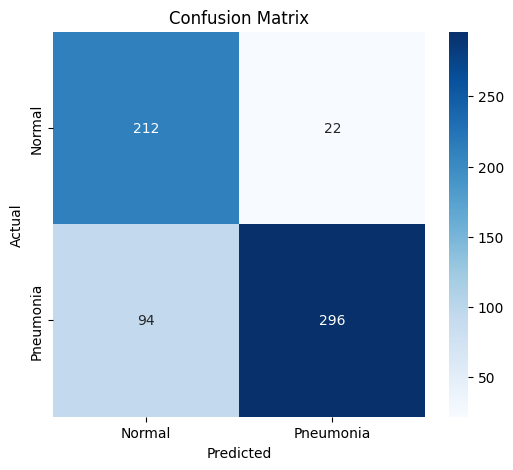

In [59]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [60]:
# Findout sensitivity and specificity
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")


Sensitivity: 75.90%
Specificity: 90.60%


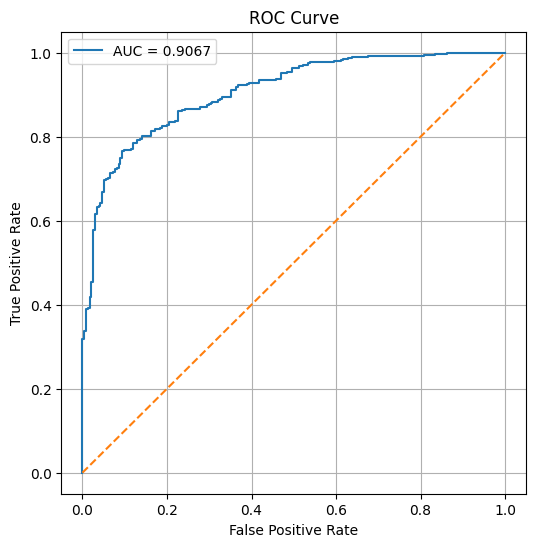

In [61]:
# Draw ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
# AUC Score
print(f"AUC Score : {auc_score:.4f}")

AUC Score : 0.8972


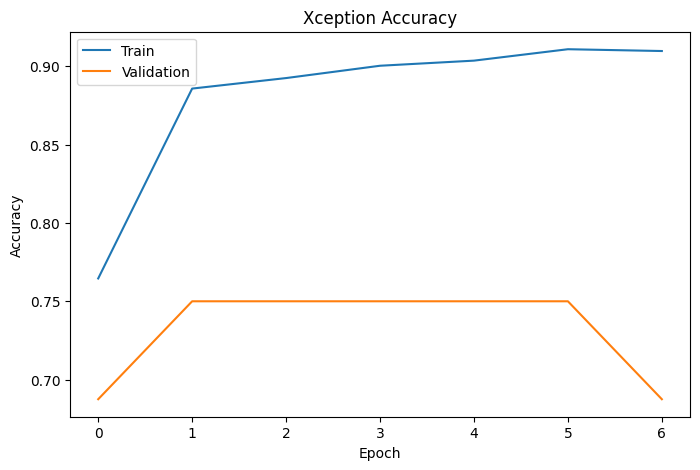

In [62]:
# Training and Validation Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Train")
plt.plot(val_acc_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Xception Accuracy")

plt.legend()

plt.show()


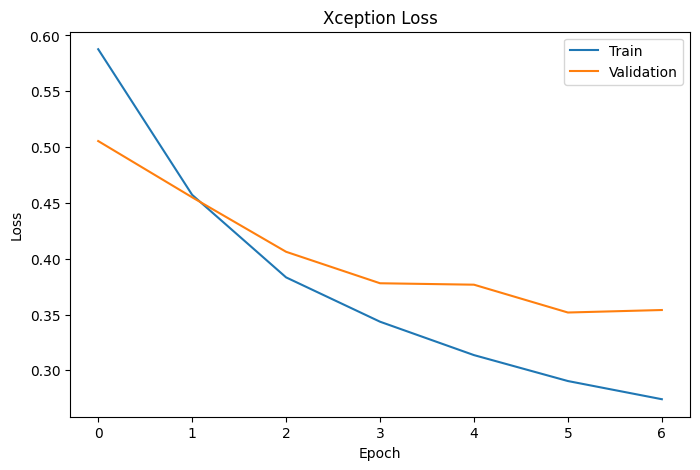

In [63]:
# Training and Validation loss Curve

plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Train")
plt.plot(val_loss_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Xception Loss")

plt.legend()

plt.show()

In [ ]:
# Perfrom Explainable AI

In [32]:
# Install GradCam Packages
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=fcaf72ebdc063f7c6cd98de1744ca5f71793890b463f81bff8805e4f7146ee12
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


In [33]:
# Import required libraries
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

In [67]:
# Extract last convolutional layer
target_layers = [model.conv4]

In [68]:
def generate_gradcam(
    model,
    image_path,
    class_names,
    target_class=None
):

    # Put model in evaluation mode
    model.eval()

    # Enable gradients for Grad-CAM
    for param in model.parameters():
        param.requires_grad = True

    # --------------------------------------------------
    # Load Image
    # --------------------------------------------------

    image = Image.open(image_path).convert("RGB")

    # Inception V3 uses 299 x 299
    resized_image = image.resize((299, 299))

    # Convert to NumPy
    rgb_img = np.array(resized_image) / 255.0

    # --------------------------------------------------
    # Transform Image
    # --------------------------------------------------

    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    with torch.no_grad():

        output = model(input_tensor)

        # In case model output is not a Tensor
        if hasattr(output, "logits"):
            output = output.logits

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

    # --------------------------------------------------
    # Target Class
    # --------------------------------------------------

    if target_class is None:
        target_class = predicted_class

    # --------------------------------------------------
    # Xception Grad-CAM Target Layer
    # --------------------------------------------------

    # Extract last convolutional layer
    target_layers = [model.conv4]

    # --------------------------------------------------
    # Create Grad-CAM
    # --------------------------------------------------

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(target_class)
    ]

    # Generate CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    # --------------------------------------------------
    # Visualization
    # --------------------------------------------------

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    # --------------------------------------------------
    # Print Results
    # --------------------------------------------------

    print(
        "Predicted Class:",
        class_names[predicted_class]
    )

    print(
        "Prediction Probability:",
        f"{probabilities[0][predicted_class].item() * 100:.2f}%"
    )

    print(
        "Grad-CAM Target:",
        class_names[target_class]
    )

    # --------------------------------------------------
    # Display
    # --------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(rgb_img)

    plt.title(
        f"Original Image\n"
        f"Prediction: {class_names[predicted_class]}"
    )

    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(visualization)

    plt.title(
        f"Grad-CAM\n"
        f"Target: {class_names[target_class]}"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

    return visualization

In [37]:
# Find NORMAL and PNEUMONIA images separately

normal_images = [
    path for path, label in test_dataset.samples
    if label == 0
]

pneumonia_images = [
    path for path, label in test_dataset.samples
    if label == 1
]

print("Number of NORMAL images:", len(normal_images))
print("Number of PNEUMONIA images:", len(pneumonia_images))

Number of NORMAL images: 234
Number of PNEUMONIA images: 390



######################################################################
GRAD-CAM FOR NORMAL IMAGES
######################################################################

NORMAL Image 1
Predicted Class: NORMAL
Prediction Probability: 61.07%
Grad-CAM Target: NORMAL


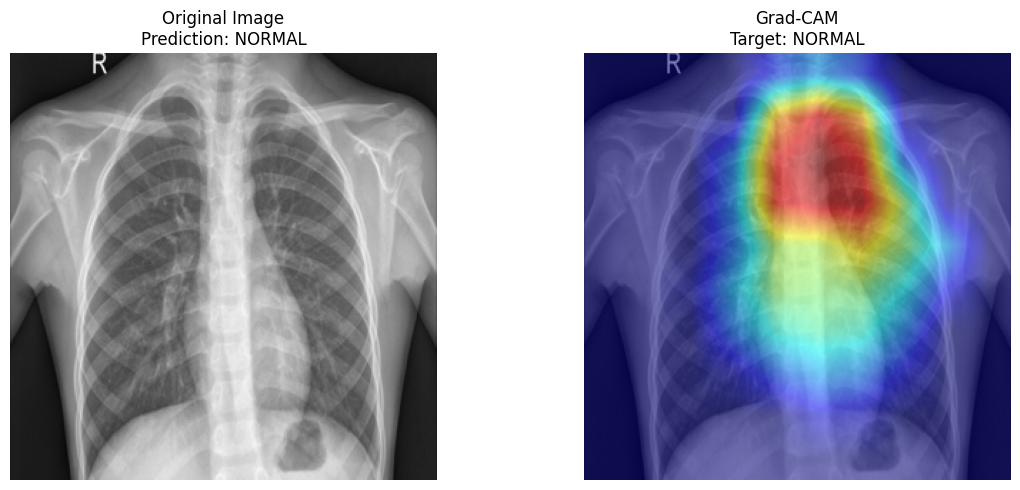


NORMAL Image 2
Predicted Class: NORMAL
Prediction Probability: 56.60%
Grad-CAM Target: NORMAL


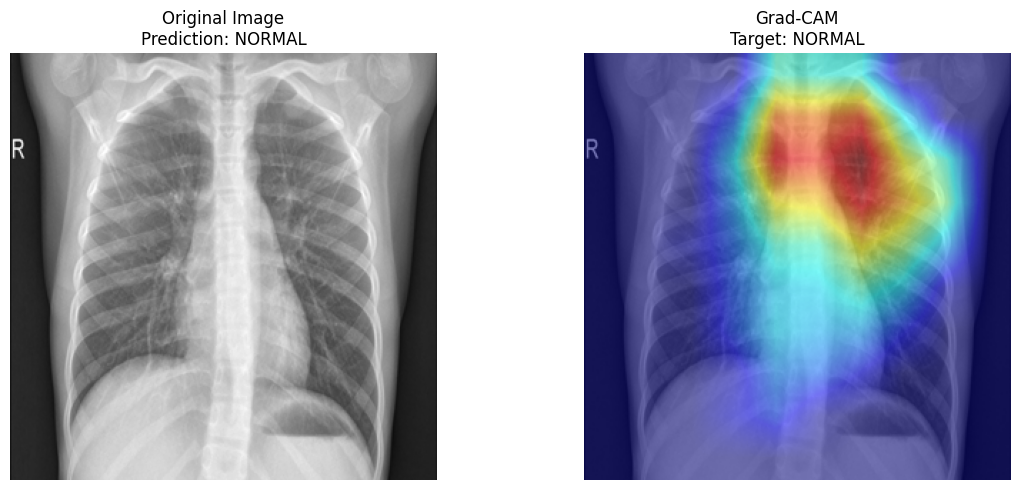


NORMAL Image 3
Predicted Class: NORMAL
Prediction Probability: 54.42%
Grad-CAM Target: NORMAL


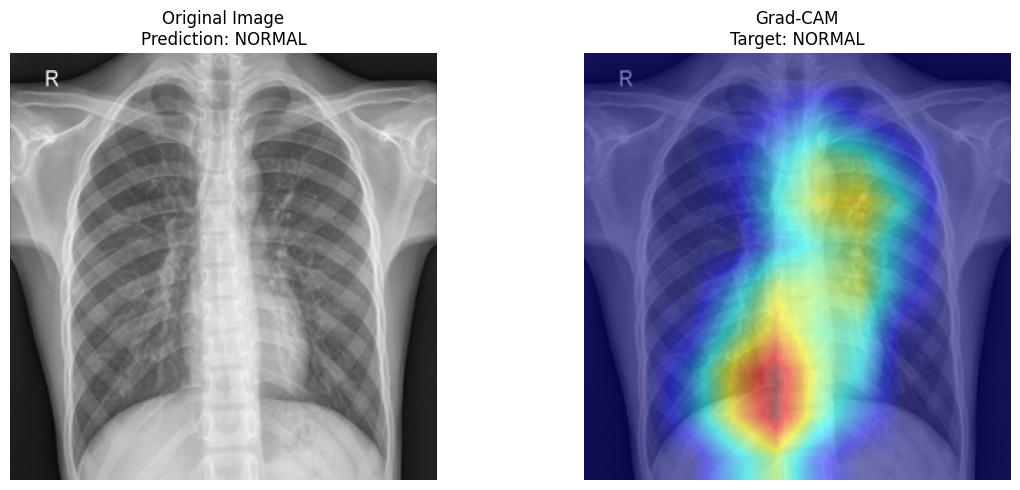


NORMAL Image 4
Predicted Class: NORMAL
Prediction Probability: 62.48%
Grad-CAM Target: NORMAL


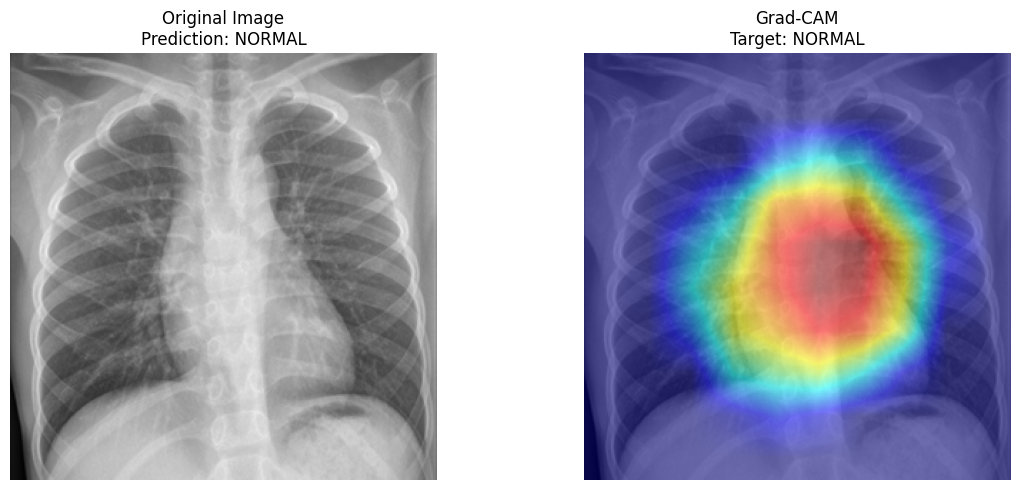


NORMAL Image 5
Predicted Class: NORMAL
Prediction Probability: 58.04%
Grad-CAM Target: NORMAL


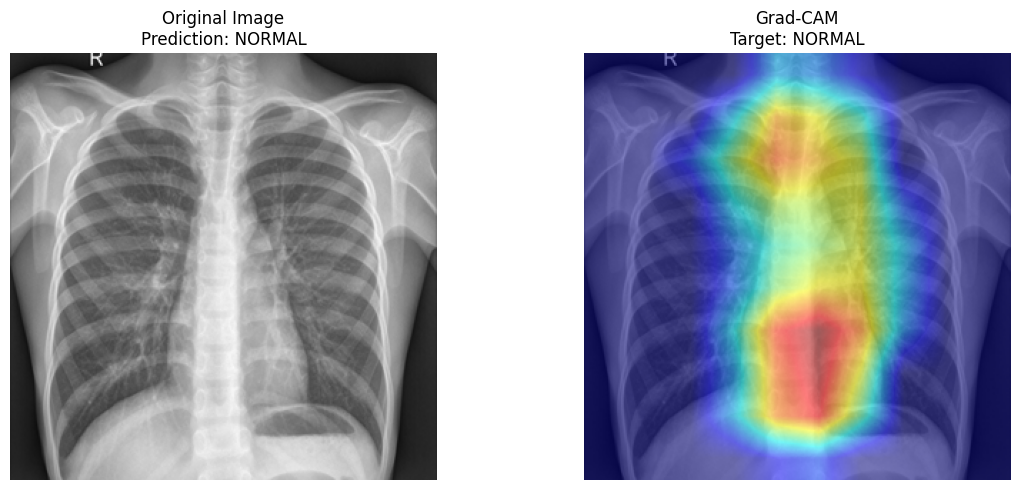

In [69]:
# Grad-CAM for 5 NORMAL images

print("\n" + "#" * 70)
print("GRAD-CAM FOR NORMAL IMAGES")
print("#" * 70)

for i in range(5):

    image_path = normal_images[i]

    print("\n" + "=" * 60)
    print(f"NORMAL Image {i+1}")

    generate_gradcam(
        model=model,
        image_path=image_path,
        class_names=test_dataset.classes
    )


######################################################################
GRAD-CAM FOR PNEUMONIA IMAGES
######################################################################

PNEUMONIA Image 1
Predicted Class: NORMAL
Prediction Probability: 63.29%
Grad-CAM Target: NORMAL


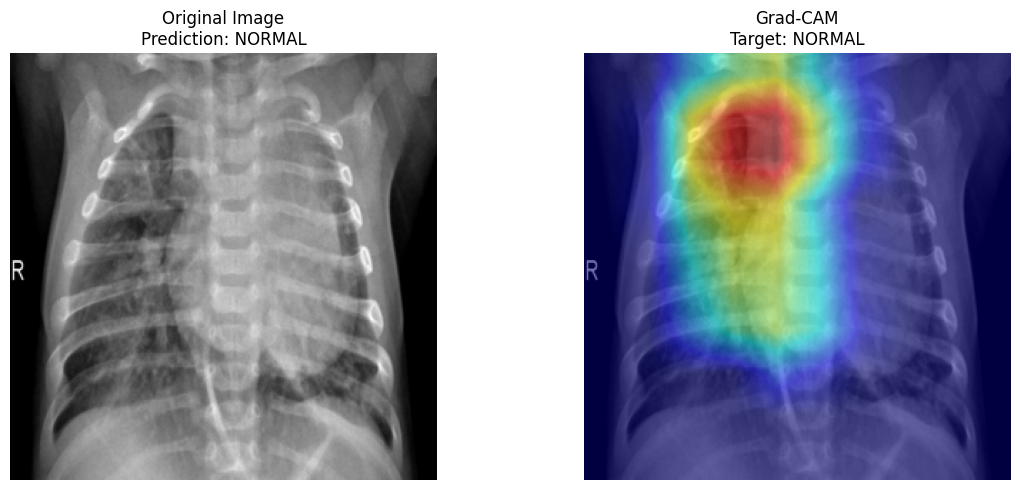


PNEUMONIA Image 2
Predicted Class: PNEUMONIA
Prediction Probability: 65.04%
Grad-CAM Target: PNEUMONIA


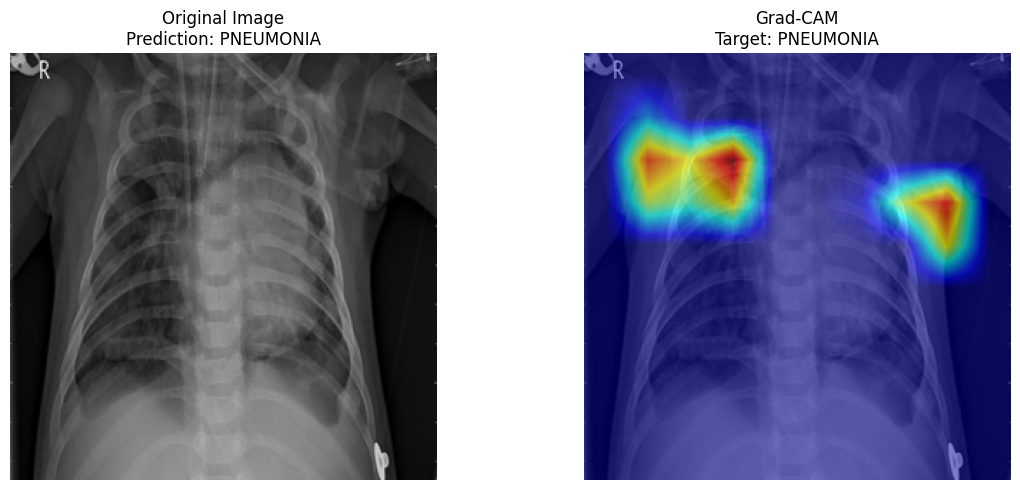


PNEUMONIA Image 3
Predicted Class: PNEUMONIA
Prediction Probability: 78.18%
Grad-CAM Target: PNEUMONIA


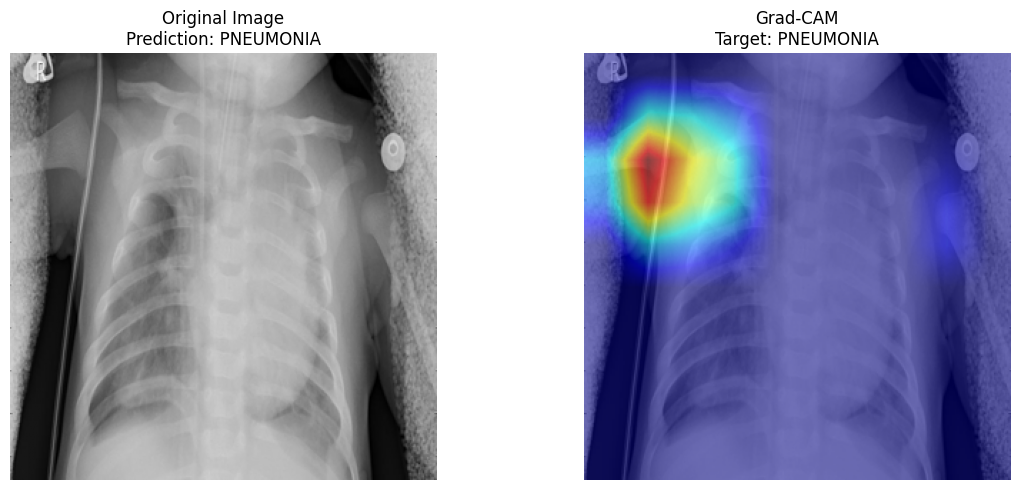


PNEUMONIA Image 4
Predicted Class: PNEUMONIA
Prediction Probability: 71.01%
Grad-CAM Target: PNEUMONIA


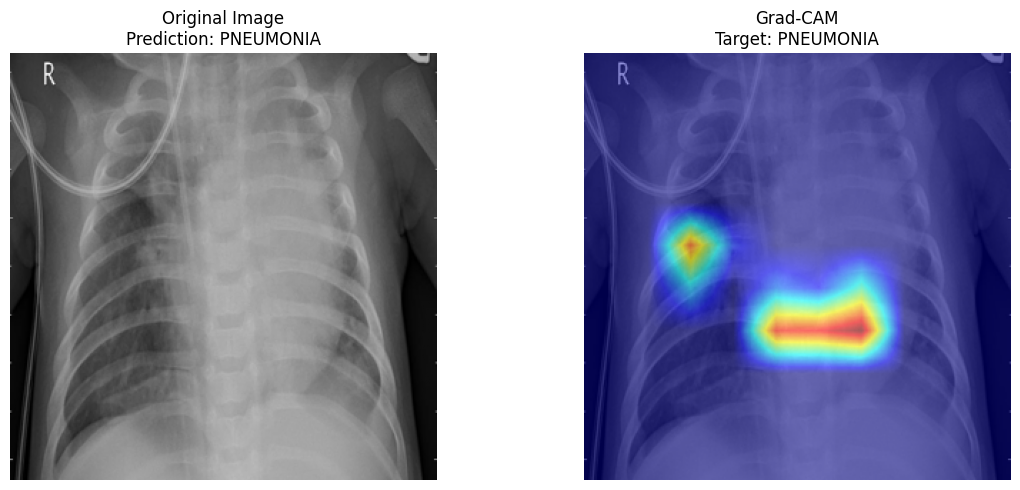


PNEUMONIA Image 5
Predicted Class: PNEUMONIA
Prediction Probability: 65.78%
Grad-CAM Target: PNEUMONIA


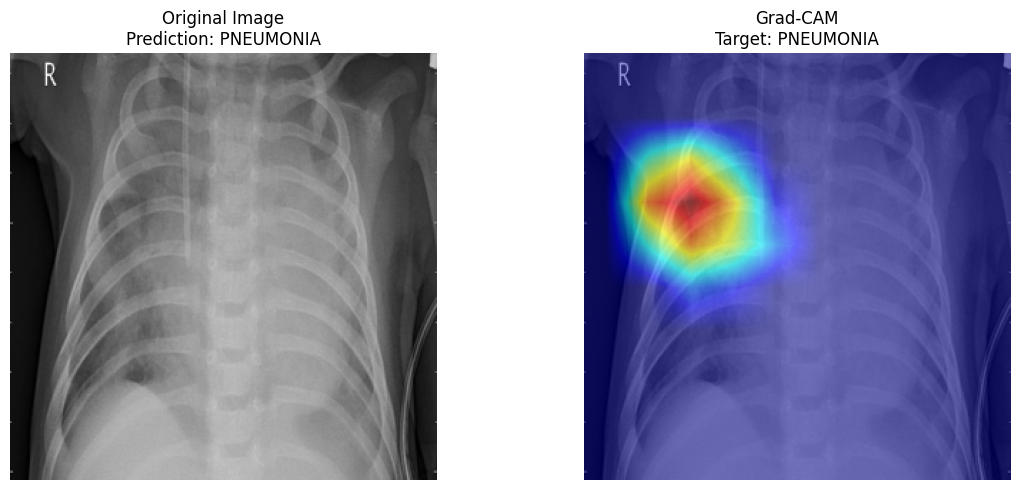

In [70]:
# Grad-CAM for 5 PNEUMONIA images

print("\n" + "#" * 70)
print("GRAD-CAM FOR PNEUMONIA IMAGES")
print("#" * 70)

for i in range(5):

    image_path = pneumonia_images[i]

    print("\n" + "=" * 60)
    print(f"PNEUMONIA Image {i+1}")

    generate_gradcam(
        model=model,
        image_path=image_path,
        class_names=test_dataset.classes
    )